#**1. Import Libraries:**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

#**2. READ FILE:**

In [4]:
#Load Dataset
df = pd.read_csv("/content/House Price Prediction Dataset.csv")

# **3. DATA CLEANING:**

In [5]:
print(df.isnull().sum())   # check missing value

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [6]:
df = df.drop_duplicates()  # remove duplicated value

In [7]:
print(df.dtypes)

Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object


#**4 Remove Unnecessary Columns:**

---



In [8]:
df.drop(['Id'], axis=1, inplace=True)

#**5. EDA(basic analysis):**

In [9]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [10]:
df.tail()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1062,5,1,2,1903,Rural,Poor,No,476925
1998,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2989,5,1,3,1903,Suburban,Fair,No,482525


In [11]:
df.describe()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       2000 non-null   int64 
 1   Bedrooms   2000 non-null   int64 
 2   Bathrooms  2000 non-null   int64 
 3   Floors     2000 non-null   int64 
 4   YearBuilt  2000 non-null   int64 
 5   Location   2000 non-null   object
 6   Condition  2000 non-null   object
 7   Garage     2000 non-null   object
 8   Price      2000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 140.8+ KB


In [13]:
df.shape

(2000, 9)

In [14]:
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location',
       'Condition', 'Garage', 'Price'],
      dtype='object')

#**DATA VISUALIZATION:**

<Figure size 1000x500 with 0 Axes>

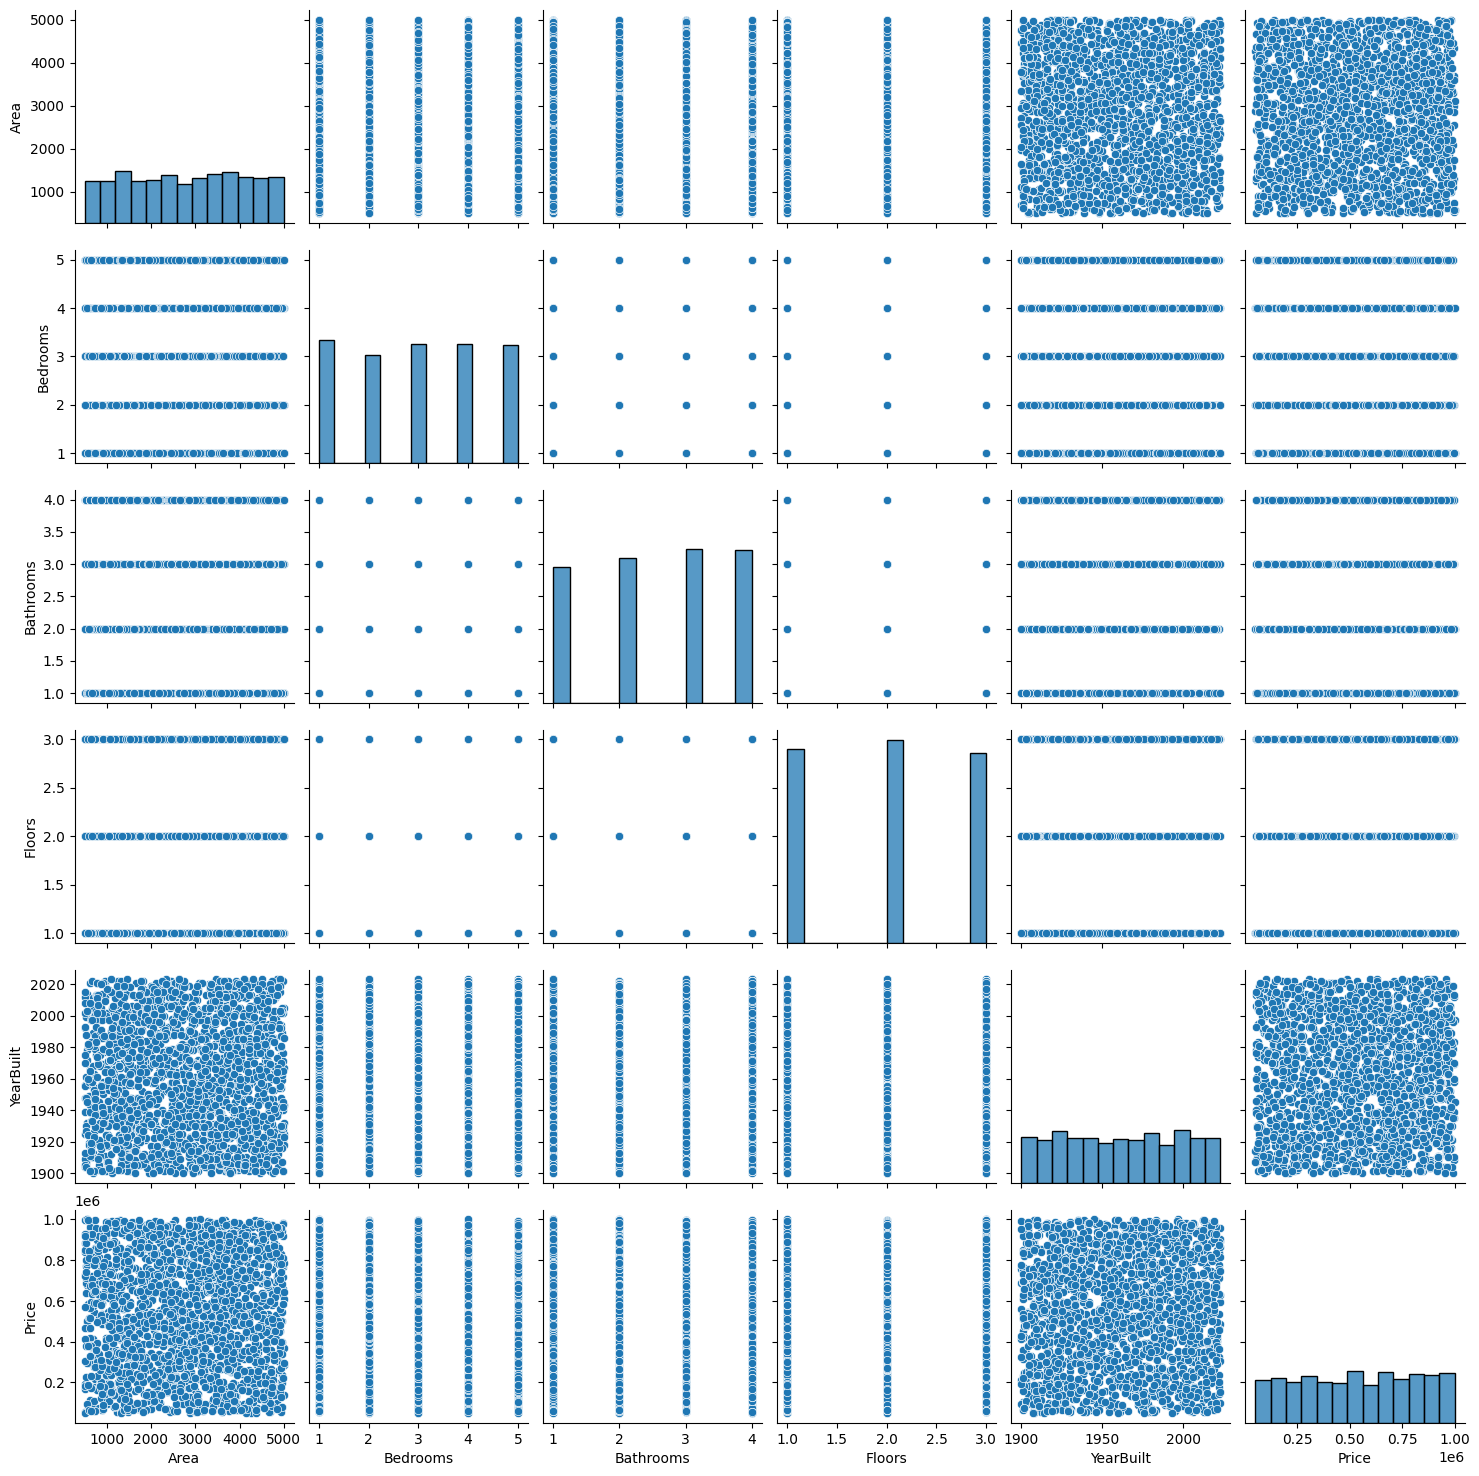

In [15]:
# Pairplot for feature relationships
plt.figure(figsize=(10, 5))
sns.pairplot(df)
plt.show()

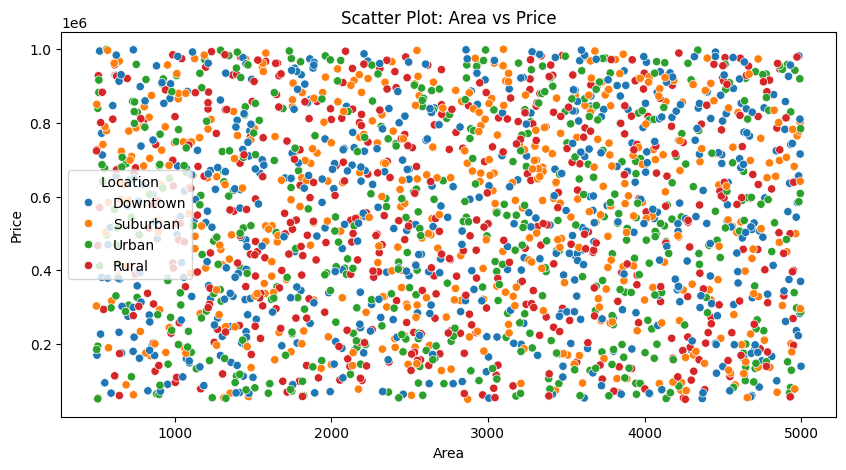

In [16]:
# Scatter Plot: Area vs Price
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['Area'], y=df['Price'], hue=df['Location'])
plt.title("Scatter Plot: Area vs Price")
plt.show()

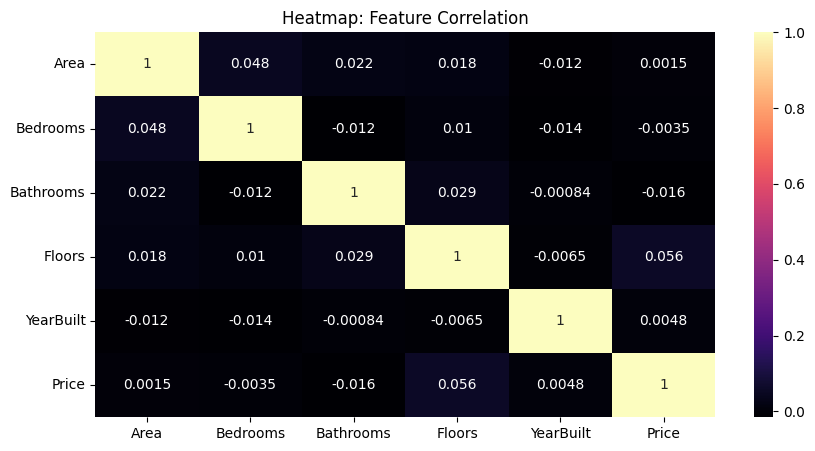

In [17]:
# Correlation Heatmap
plt.figure(figsize=(10, 5))
numerical_df = df.select_dtypes(include=np.number)
correlation = numerical_df.corr()
sns.heatmap(correlation, annot=True, cmap='magma')
plt.title("Heatmap: Feature Correlation")
plt.show()
# Observation: Light/Red = Strong correlation

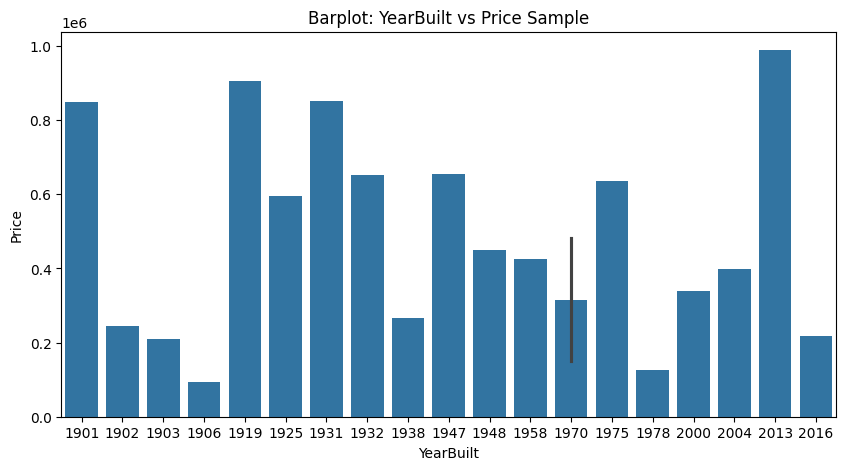

In [18]:
# Barplot for YearBuilt vs Price
plt.figure(figsize=(10, 5))
sns.barplot(x=df['YearBuilt'].head(20), y=df['Price'].head(20))
plt.title("Barplot: YearBuilt vs Price Sample")
plt.show()

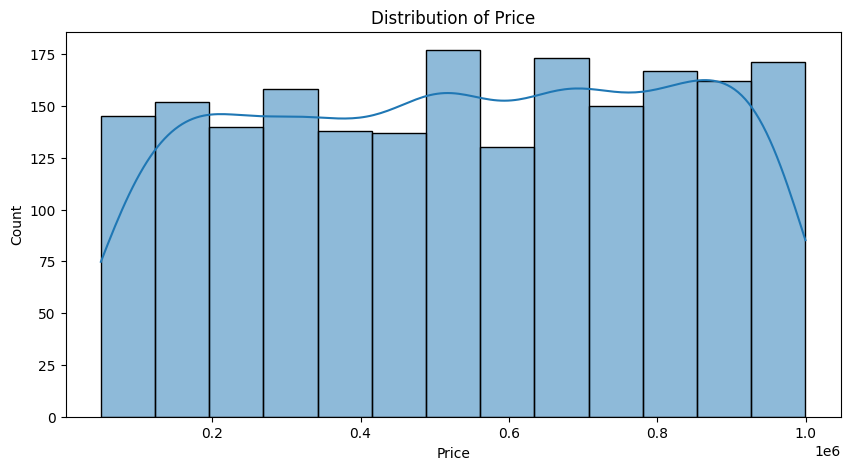

In [19]:
# Distribution of Price
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Price')
plt.show()

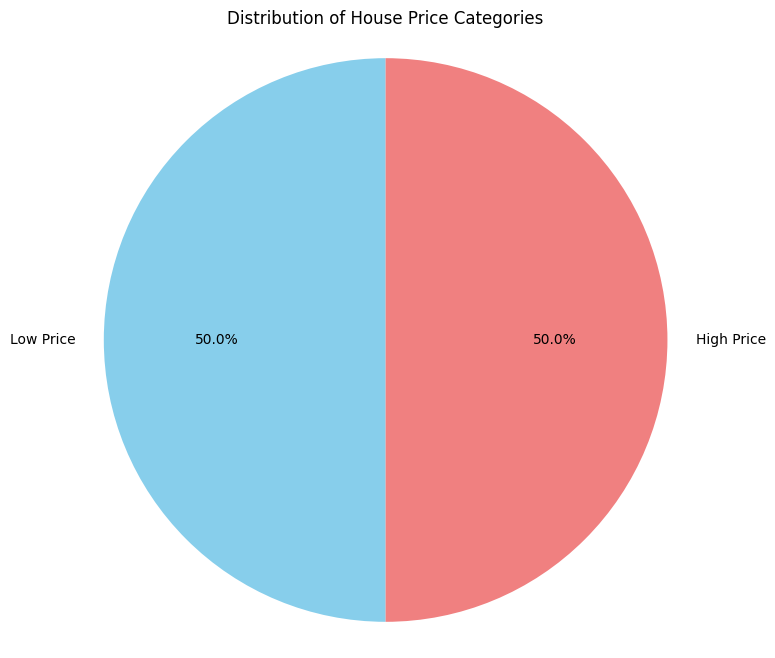

In [20]:
# Create 'price_category' column based on median price
median_price = df['Price'].median()
df['price_category'] = df['Price'].apply(lambda x: 'High Price' if x >= median_price else 'Low Price')

# Pie Chart for Target Distribution
price_category_counts = df['price_category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(price_category_counts, labels=price_category_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of House Price Categories')
plt.axis('equal')
plt.show()

# **7. PREPROCESSING:**

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
# Create target column
X = df.drop('Price', axis=1)
y = df['Price']

In [23]:
from sklearn.preprocessing import StandardScaler

# Feature scaling for numerical stability
scaler = StandardScaler()                # feacher scalling
X = scaler.fit_transform(X)

#8**TRAIN TEST SPLIT:**

In [24]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#**9.APPLYING MODELS:**

##Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression

# Linear Regression model train
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_lr = model.predict(X_test)

##**Decision Tree Regressor:**

In [26]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree model train
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

##**Random Forest Regressor:**

In [27]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest model train
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#**10 CHECK ACCURACY:**

In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Linear Regression Evaluation
print("Linear Regression")
# Accuracy ki jagah regression mein R2 Score use hota hai
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_lr))

Linear Regression
R2 Score: 0.7515136146099597
Mean Absolute Error: 119608.00378880785


In [29]:
# Decision Tree Evaluation
print("Decision Tree")
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_dt))

Decision Tree
R2 Score: 0.4729450966233131
Mean Absolute Error: 165637.22


In [30]:
# Random Forest Evaluation
print("Random Forest")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_rf))

Random Forest
R2 Score: 0.733067950970228
Mean Absolute Error: 123584.72614999999


#**11.VISUALIZATION OF PREDICTIONS:**

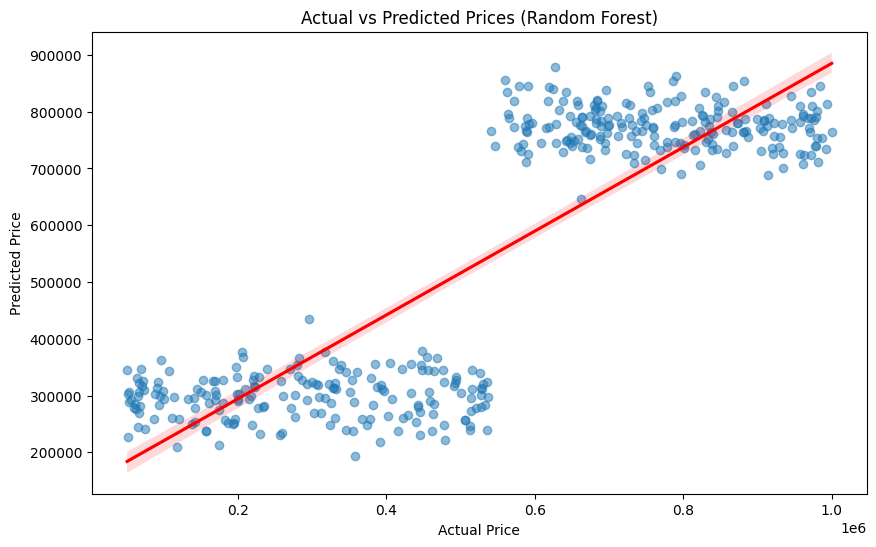

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest predictions or actual values To see the difference
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_rf, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

#**12.Model Comparison:**

In [32]:
from sklearn.metrics import r2_score

#Every model ka R2 score calculate
score_lr = r2_score(y_test, y_pred_lr)
score_dt = r2_score(y_test, y_pred_dt)
score_rf = r2_score(y_test, y_pred_rf)

print(f"Linear Regression R2 Score: {score_lr}")
print(f"Decision Tree R2 Score: {score_dt}")
print(f"Random Forest R2 Score: {score_rf}")

Linear Regression R2 Score: 0.7515136146099597
Decision Tree R2 Score: 0.4729450966233131
Random Forest R2 Score: 0.733067950970228


#**FINAL PERFORMANCE SUMMARY:**

In [33]:
# Calculating the average R2 score across all regression models
avg_score = (score_lr + score_dt + score_rf) / 3

print("Average R2 Score for House Price Models:", avg_score)

Average R2 Score for House Price Models: 0.652508887401167


#**CONCLUSION**
##**Observations:**

* humne models ko compare kiya hai, wahi logic humne house prices ke liye r2_score par apply kiya hai.

* Regression mein Confusion Matrix nahi hota, isliye humne regplot use kiya hai